# Módulo 5: Comparación Final de los Tres Tipos de Reaseguro 

Comparamos visualmente el impacto de los tres tratados de reaseguro
sobre la distribución de pérdidas retenidas por la aseguradora.

## Tratados comparados
- **Bruto**: sin reaseguro
- **Quota Share**: $\alpha = 0.40$
- **Excess of Loss**: $M = 100,000$, $L = 400,000$
- **Stop-Loss**: $D = 150,000$, $C = 5,000,000$

In [ ]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from src.treaties import apply_quota_share, apply_excess_of_loss, apply_stop_loss

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Cargar datos
df          = pd.read_csv("../data/simulated_losses.csv")
S_pareto    = df["S_pareto"].values

# Cuota Parte
ret_qs = apply_quota_share(S_pareto, alpha=0.40)["retained"]

# Stop-Loss
ret_sl = apply_stop_loss(S_pareto, D=150_000.0, C=5_000_000.0)["retained"]

# Excess of Loss (resimular con misma semilla)
rng = np.random.default_rng(42)
N   = rng.poisson(lam=50.0, size=100_000)
ret_xl = np.zeros(100_000)
for i, n in enumerate(N):
    if n == 0:
        continue
    U = rng.uniform(size=n)
    Y = 1_000.0 / (U ** (1.0 / 1.5))
    res = apply_excess_of_loss(Y, M=100_000.0, L=400_000.0)
    ret_xl[i] = res["retained"].sum()

print("Datos listos")
print(f"Bruto  media: {S_pareto.mean():,.0f}")
print(f"QS     media: {ret_qs.mean():,.0f}")
print(f"XL     media: {ret_xl.mean():,.0f}")
print(f"SL     media: {ret_sl.mean():,.0f}")

Datos listos
Bruto  media: 149,069
QS     media: 89,441
XL     media: 139,920
SL     media: 128,144


## Gráfica 1: Distribuciones comparativas de pérdida retenida

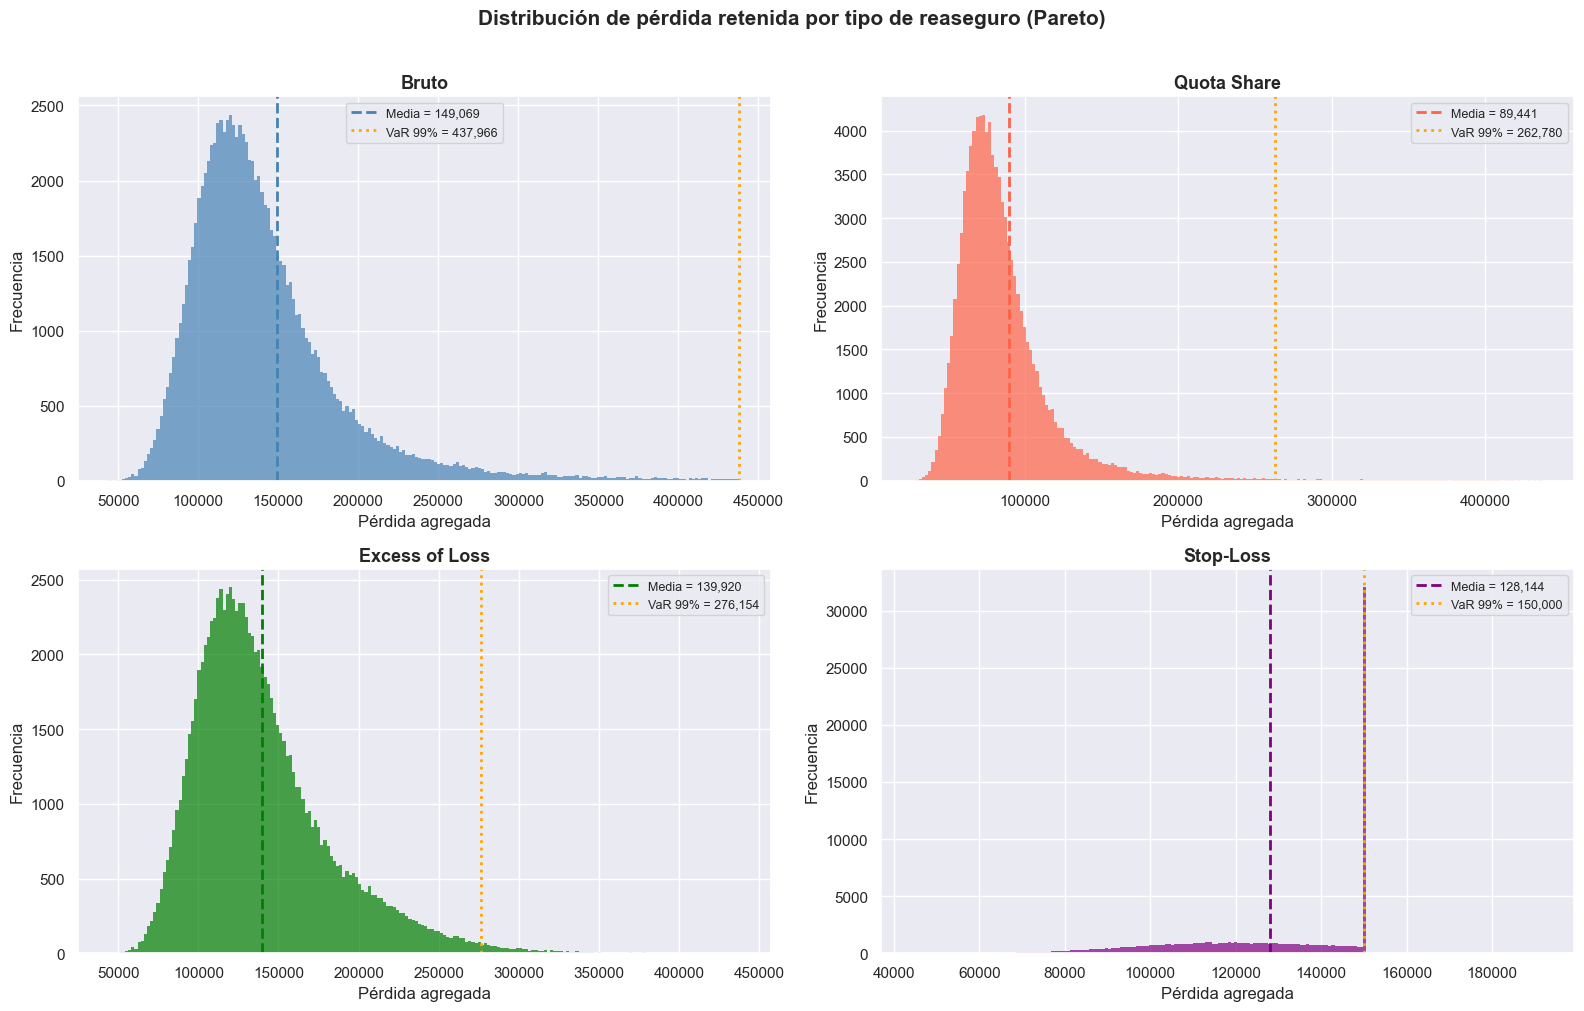

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

x_max = np.percentile(S_pareto, 99)
colores = ["steelblue", "tomato", "green", "purple"]
datos   = [S_pareto, ret_qs, ret_xl, ret_sl]
nombres = ["Bruto", "Quota Share", "Excess of Loss", "Stop-Loss"]

for ax, S, nombre, color in zip(axes.flatten(), datos, nombres, colores):
    S_zoom = S[S <= x_max]
    ax.hist(S_zoom, bins=200, alpha=0.7, color=color, edgecolor="none")
    ax.axvline(S.mean(),                color=color,   linewidth=2, linestyle="--", label=f"Media = {S.mean():,.0f}")
    ax.axvline(np.percentile(S, 99),    color="orange", linewidth=2, linestyle=":", label=f"VaR 99% = {np.percentile(S,99):,.0f}")
    ax.set_title(nombre, fontsize=13, fontweight="bold")
    ax.set_xlabel("Pérdida agregada")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=9)

plt.suptitle("Distribución de pérdida retenida por tipo de reaseguro (Pareto)", 
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../figures/06_distribuciones_comparativas.png", dpi=150, bbox_inches="tight")
plt.show()

## Gráfica 2: ECDF comparativa de los cuatro escenarios

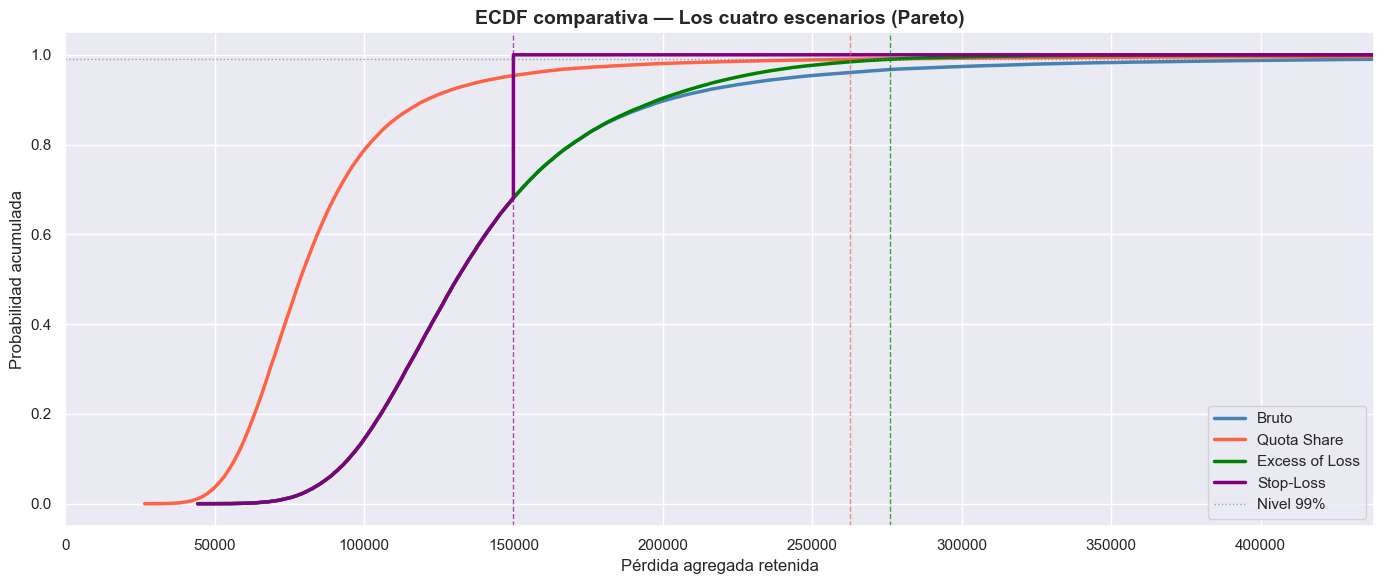

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

colores = ["steelblue", "tomato", "green", "purple"]
datos   = [S_pareto, ret_qs, ret_xl, ret_sl]
nombres = ["Bruto", "Quota Share", "Excess of Loss", "Stop-Loss"]

x_max = np.percentile(S_pareto, 99)

for S, nombre, color in zip(datos, nombres, colores):
    S_sorted = np.sort(S)
    prob     = np.arange(1, len(S_sorted) + 1) / len(S_sorted)
    ax.plot(S_sorted, prob, color=color, linewidth=2.5, label=nombre)

# VaR 99% de cada tratado
for S, nombre, color in zip(datos, nombres, colores):
    var99 = np.percentile(S, 99)
    ax.axvline(var99, color=color, linewidth=1, linestyle="--", alpha=0.7)

ax.axhline(0.99, color="gray", linewidth=1, linestyle=":", alpha=0.7, label="Nivel 99%")
ax.set_xlim(0, x_max)
ax.set_title("ECDF comparativa — Los cuatro escenarios (Pareto)", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Pérdida agregada retenida")
ax.set_ylabel("Probabilidad acumulada")
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("../figures/07_ecdf_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()

## Gráfica 3: Comparación de métricas actuariales

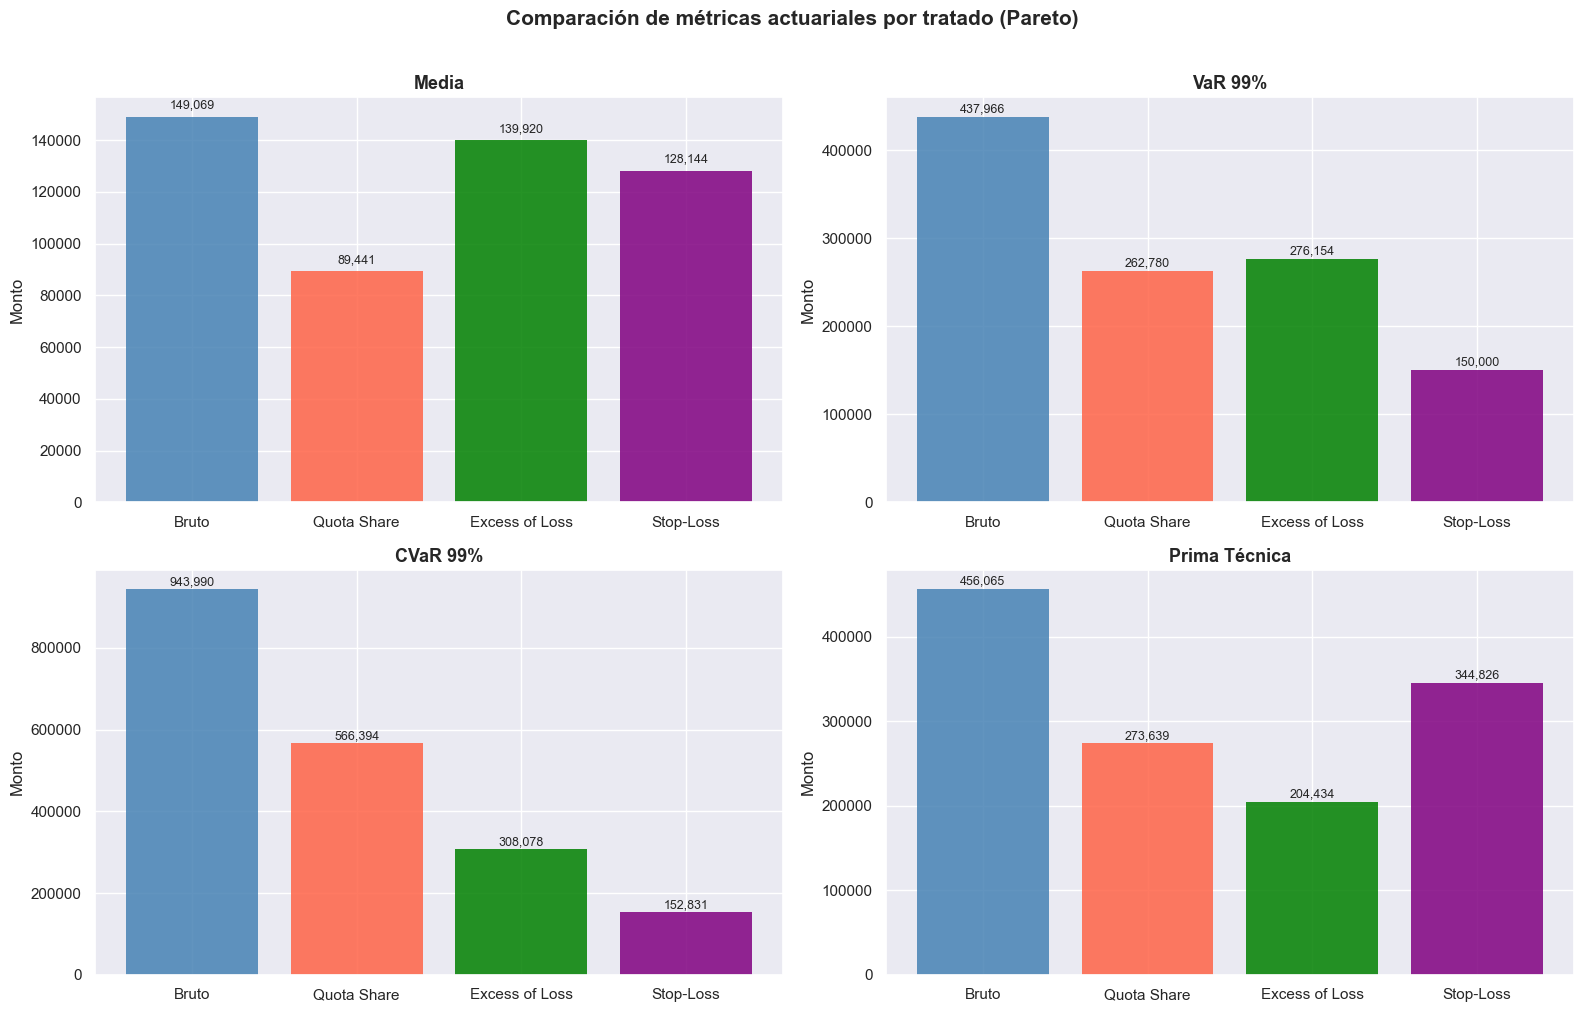

In [ ]:
# Calcular métricas
def metricas(S, nombre):
    var99  = np.percentile(S, 99)
    cvar99 = S[S > var99].mean()
    media  = S.mean()
    std    = S.std()
    prima  = media + 1.5 * std
    return {"Tratado": nombre, "Media": media, "VaR 99%": var99,
            "CVaR 99%": cvar99, "Prima Técnica": prima}

df_met = pd.DataFrame([
    metricas(S_pareto, "Bruto"),
    metricas(ret_qs,   "Quota Share"),
    metricas(ret_xl,   "Excess of Loss"),
    metricas(ret_sl,   "Stop-Loss"),
]).set_index("Tratado")

# Gráfica de barras
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colores   = ["steelblue", "tomato", "green", "purple"]
metricas_cols = ["Media", "VaR 99%", "CVaR 99%", "Prima Técnica"]

for ax, col in zip(axes.flatten(), metricas_cols):
    bars = ax.bar(df_met.index, df_met[col], color=colores, edgecolor="none", alpha=0.85)
    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_ylabel("Monto")
    ax.set_xlabel("")
    for bar, val in zip(bars, df_met[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                f"{val:,.0f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Comparación de métricas actuariales por tratado (Pareto)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../figures/08_metricas_comparativas.png", dpi=150, bbox_inches="tight")
plt.show()

## Gráfica 4: Loss Layer Diagram

Muestra visualmente las capas de cada tratado para distintos
niveles de pérdida. ¿Cuánto retiene la aseguradora y cuánto
cubre el reasegurador en cada escenario?

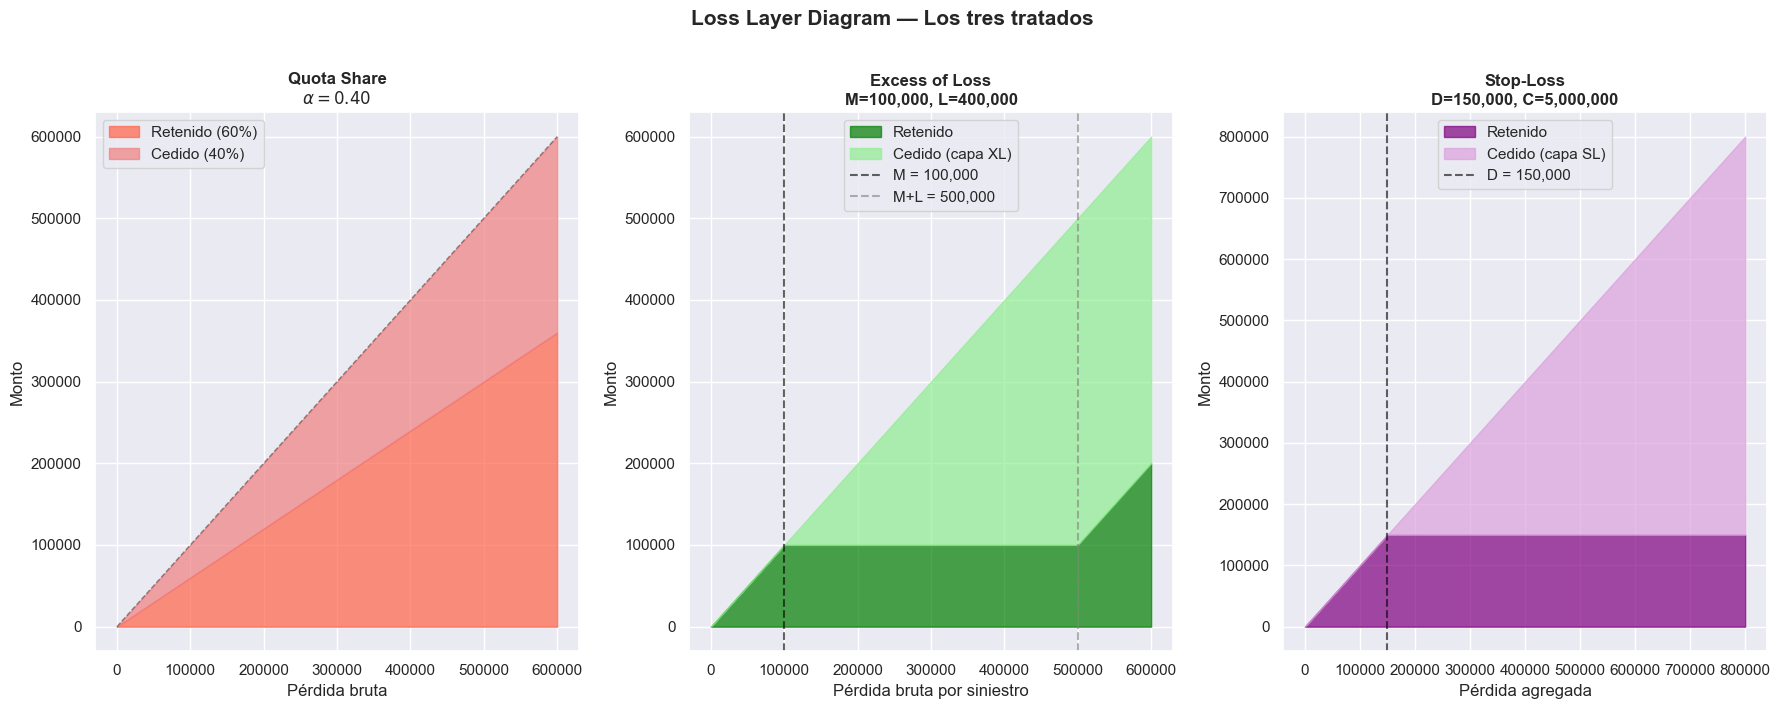

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

niveles = np.linspace(0, 600_000, 1000)

#  Quota Share 
alpha = 0.40
ret_qs_layer = (1 - alpha) * niveles
ced_qs_layer = alpha * niveles

axes[0].fill_between(niveles, 0, ret_qs_layer,
                     alpha=0.7, color="tomato",    label=f"Retenido (60%)")
axes[0].fill_between(niveles, ret_qs_layer, niveles,
                     alpha=0.7, color="lightcoral", label=f"Cedido (40%)")
axes[0].plot(niveles, niveles, color="black", linewidth=1, linestyle="--", alpha=0.4)
axes[0].set_title("Quota Share\n" + r"$\alpha = 0.40$", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Pérdida bruta")
axes[0].set_ylabel("Monto")
axes[0].legend()

#  Excess of Loss 
M, L = 100_000, 400_000
ret_xl_layer = np.minimum(niveles, M) + np.maximum(niveles - M - L, 0)
ced_xl_layer = np.minimum(np.maximum(niveles - M, 0), L)

axes[1].fill_between(niveles, 0, ret_xl_layer,
                     alpha=0.7, color="green",      label=f"Retenido")
axes[1].fill_between(niveles, ret_xl_layer, ret_xl_layer + ced_xl_layer,
                     alpha=0.7, color="lightgreen",  label=f"Cedido (capa XL)")
axes[1].axvline(M,   color="black", linewidth=1.5, linestyle="--", alpha=0.6, label=f"M = {M:,}")
axes[1].axvline(M+L, color="gray",  linewidth=1.5, linestyle="--", alpha=0.6, label=f"M+L = {M+L:,}")
axes[1].set_title("Excess of Loss\n" + f"M={M:,}, L={L:,}", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Pérdida bruta por siniestro")
axes[1].set_ylabel("Monto")
axes[1].legend()

#  Stop-Loss
D, C = 150_000, 5_000_000
niveles_sl = np.linspace(0, 800_000, 1000)
ced_sl_layer = np.minimum(np.maximum(niveles_sl - D, 0), C)
ret_sl_layer = niveles_sl - ced_sl_layer

axes[2].fill_between(niveles_sl, 0, ret_sl_layer,
                     alpha=0.7, color="purple",     label="Retenido")
axes[2].fill_between(niveles_sl, ret_sl_layer, ret_sl_layer + ced_sl_layer,
                     alpha=0.7, color="plum",        label="Cedido (capa SL)")
axes[2].axvline(D,   color="black", linewidth=1.5, linestyle="--", alpha=0.6, label=f"D = {D:,}")
axes[2].set_title("Stop-Loss\n" + f"D={D:,}, C={C:,}", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Pérdida agregada")
axes[2].set_ylabel("Monto")
axes[2].legend()

plt.suptitle("Loss Layer Diagram — Los tres tratados",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../figures/09_loss_layer_diagram.png", dpi=150, bbox_inches="tight")
plt.show()